# 04 — Model Tuning with XGBoost & LightGBM
**Goal:** Replace Random Forest with gradient boosting models and tune key hyperparameters.

| Version | Model | Kaggle Public |
|---|---|---|
| v1 | RF Baseline | 25,943.38 |
| v2 | RF + Feature Eng | 27,582.06 |
| v3 | XGBoost + Feature Eng | _(submit)_ |
| v4 | LightGBM + Feature Eng | _(submit)_ |


---
## 1. Why XGBoost / LightGBM over Random Forest?

| | Random Forest | XGBoost / LightGBM |
|---|---|---|
| How it builds trees | All trees built **independently** in parallel | Each tree **corrects errors** from previous tree |
| Handles engineered features | Already good at finding patterns in raw features | Benefits more from explicit engineered features |
| Speed | Slower on large data | Much faster (LightGBM especially) |
| Typical competition performance | Good baseline | Usually **top performer** in tabular data |

> **Key idea — Gradient Boosting:** Start with a simple prediction (e.g. mean price). Build a tree to predict the **residual error**. Add that tree to the model. Repeat 100–1000 times. Each iteration focuses on the hardest-to-predict rows.


---
## 2. Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from math import radians, cos, sin, asin, sqrt

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_squared_error

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

train = pd.read_csv('../../data/raw/train.csv')
test  = pd.read_csv('../../data/raw/test.csv', low_memory=False)
print(f'Train: {train.shape}  |  Test: {test.shape}')

Train: (150634, 77)  |  Test: (16737, 76)


---
## 3. Apply Feature Engineering
All functions from notebook 03 — applied identically to train and test.


In [2]:
# ── Drop & fill constants ─────────────────────────────────────────────
DROP_COLS = [
    'floor_area_sqft','lower','upper','mid','full_flat_type',
    'address','Tranc_YearMonth','residential','year_completed',
]
SOLD_COLS   = ['1room_sold','2room_sold','3room_sold','4room_sold',
               '5room_sold','exec_sold','multigen_sold','studio_apartment_sold']
RENTAL_COLS = ['1room_rental','2room_rental','3room_rental','other_room_rental']
FILL_ZERO   = ['Hawker_Within_500m','Mall_Within_500m','Hawker_Within_1km',
               'Mall_Within_1km','Hawker_Within_2km','Mall_Within_2km']
MATURE_ESTATES = {
    'ANG MO KIO','BEDOK','BISHAN','BUKIT MERAH','BUKIT TIMAH',
    'CENTRAL AREA','CLEMENTI','GEYLANG','KALLANG/WHAMPOA',
    'MARINE PARADE','PASIR RIS','QUEENSTOWN','SERANGOON','TAMPINES','TOA PAYOH'
}
ROOM_COUNT = {'1 ROOM':1,'2 ROOM':2,'3 ROOM':3,'4 ROOM':4,
              '5 ROOM':5,'EXECUTIVE':5,'MULTI-GENERATION':6}
CBD_LAT, CBD_LON = 1.2847, 103.8510

def haversine_km(lat, lon, lat2=CBD_LAT, lon2=CBD_LON):
    R = 6371
    lat, lon, lat2, lon2 = map(radians, [lat, lon, lat2, lon2])
    a = sin((lat2-lat)/2)**2 + cos(lat)*cos(lat2)*sin((lon2-lon)/2)**2
    return 2*R*asin(sqrt(a))

def engineer_features(df, town_price_map=None):
    df = df.copy()
    # Fill zeros
    for c in FILL_ZERO:
        df[c] = df[c].fillna(0)
    # Tier 1
    df['remaining_lease']  = 99 - (df['Tranc_Year'] - df['lease_commence_date'])
    df['dist_to_cbd']      = df.apply(lambda r: haversine_km(r['Latitude'], r['Longitude']), axis=1)
    df['is_mature_estate'] = df['town'].str.upper().isin(MATURE_ESTATES).astype(int)
    # Tier 2
    df['tranc_month_sin']     = np.sin(2*np.pi*df['Tranc_Month']/12)
    df['tranc_month_cos']     = np.cos(2*np.pi*df['Tranc_Month']/12)
    df['total_sold']          = df[SOLD_COLS].sum(axis=1)
    df['total_rental']        = df[RENTAL_COLS].sum(axis=1)
    df['rental_ratio']        = (df['total_rental'] / df['total_dwelling_units'].replace(0,np.nan)).fillna(0)
    df['num_rooms']           = df['flat_type'].str.upper().map(ROOM_COUNT).fillna(4)
    df['floor_area_per_room'] = df['floor_area_sqm'] / df['num_rooms']
    # Tier 3
    if town_price_map is not None:
        df['town_median_price'] = df['town'].map(town_price_map).fillna(town_price_map.median())
    for col in ['mrt_nearest_distance','Mall_Nearest_Distance','Hawker_Nearest_Distance']:
        cap = df[col].quantile(0.99)
        inv = 1/(df[col].clip(1,cap))
        df[f'_{col}_inv'] = (inv-inv.min())/(inv.max()-inv.min())
    df['amenity_score'] = (df['_mrt_nearest_distance_inv'] +
                           df['_Mall_Nearest_Distance_inv'] +
                           df['_Hawker_Nearest_Distance_inv']) / 3
    df.drop(columns=[c for c in df.columns if c.startswith('_') and c.endswith('_inv')], inplace=True)
    return df

# Fit town encoding on train only
town_price_map = train.groupby('town')['resale_price'].median()

train_fe = engineer_features(train, town_price_map)
test_fe  = engineer_features(test,  town_price_map)
print('Feature engineering done.')
print(f'Train: {train_fe.shape}  |  Test: {test_fe.shape}')

Feature engineering done.
Train: (150634, 89)  |  Test: (16737, 88)


---
## 4. Prepare X and y

In [3]:
DROP_ALL = ['id','resale_price'] + DROP_COLS + SOLD_COLS + RENTAL_COLS + ['num_rooms']

X      = train_fe.drop(columns=DROP_ALL, errors='ignore')
y      = train_fe['resale_price']
X_test = test_fe.drop(columns=[c for c in DROP_ALL if c != 'resale_price'], errors='ignore')
X_test = X_test.reindex(columns=X.columns, fill_value=0)

num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

# Cast categoricals to string (postal has mixed types)
for col in cat_cols:
    X[col]      = X[col].astype(str)
    X_test[col] = X_test[col].astype(str)

print(f'Features: {X.shape[1]}  (num={len(num_cols)}, cat={len(cat_cols)})')

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

Features: 65  (num=49, cat=16)


---
## 5. Preprocessing Pipeline

> XGBoost and LightGBM can handle missing values natively, but we still use the same pipeline structure for consistency. We use **OrdinalEncoder** to convert categorical strings to integers — both models work well with this.


In [4]:
num_pipe = Pipeline([('imp', SimpleImputer(strategy='median'))])
cat_pipe = Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                     ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))])
preprocessor = ColumnTransformer([('num', num_pipe, num_cols),
                                   ('cat', cat_pipe, cat_cols)])

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def evaluate(name, model, X_tr, y_tr, X_v, y_v):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_v)
    r = rmse(y_v, pred)
    r2 = 1 - mean_squared_error(y_v, pred)/np.var(y_v)
    print(f'{name:<35} RMSE=${r:>8,.0f}   R²={r2:.4f}')
    return r

---
## 6. XGBoost — Default Start

**Key hyperparameters explained:**
| Parameter | What it does | Typical range |
|---|---|---|
| `n_estimators` | Number of trees (boosting rounds) | 300–1000 |
| `max_depth` | How deep each tree grows | 3–8 |
| `learning_rate` | How much each tree contributes | 0.01–0.3 |
| `subsample` | % of rows each tree sees (reduces overfitting) | 0.6–1.0 |
| `colsample_bytree` | % of columns each tree sees | 0.6–1.0 |
| `min_child_weight` | Min samples in a leaf | 1–10 |

> **Rule of thumb:** Lower `learning_rate` + more `n_estimators` = better, but slower.


In [5]:
xgb_default = Pipeline([
    ('pre', preprocessor),
    ('model', XGBRegressor(
        n_estimators     = 500,
        max_depth        = 6,
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        min_child_weight = 5,
        random_state     = 42,
        n_jobs           = -1,
        verbosity        = 0,
    ))
])

xgb_val_rmse = evaluate('XGBoost (default)', xgb_default, X_train, y_train, X_val, y_val)
print(f'RF Baseline val RMSE:  $25,871')

XGBoost (default)                   RMSE=$  23,649   R²=0.9726
RF Baseline val RMSE:  $25,871


---
## 7. LightGBM — Default Start

LightGBM is similar to XGBoost but faster. It grows trees **leaf-wise** (deepest leaf first) instead of level-wise, which often gives better accuracy.

Key extra parameter: `num_leaves` — controls tree complexity. Rule: `num_leaves < 2^max_depth`.


In [6]:
lgbm_default = Pipeline([
    ('pre', preprocessor),
    ('model', LGBMRegressor(
        n_estimators     = 500,
        max_depth        = 6,
        num_leaves       = 40,
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        min_child_samples= 20,
        random_state     = 42,
        n_jobs           = -1,
        verbosity        = -1,
    ))
])

lgbm_val_rmse = evaluate('LightGBM (default)', lgbm_default, X_train, y_train, X_val, y_val)

LightGBM (default)                  RMSE=$  24,018   R²=0.9717


---
## 8. Cross-Validation — Pick the Better Model

In [7]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, pipe in [('XGBoost ', xgb_default), ('LightGBM', lgbm_default)]:
    scores = -cross_val_score(pipe, X, y, cv=kf,
                               scoring='neg_root_mean_squared_error', n_jobs=-1)
    print(f'{name}  CV RMSE: ${scores.mean():>8,.0f} ± ${scores.std():,.0f}')

print(f'RF v1 baseline CV RMSE: $26,389')

XGBoost   CV RMSE: $  23,932 ± $328


LightGBM  CV RMSE: $  24,348 ± $282
RF v1 baseline CV RMSE: $26,389


---
## 9. Hyperparameter Tuning — RandomizedSearchCV

Instead of trying every combination (**GridSearch** = exhaustive, very slow), **RandomizedSearch** randomly samples N combinations — much faster, usually finds a good result.

We tune the better-performing model from Section 8.


In [8]:
from scipy.stats import randint, uniform

param_dist = {
    'model__n_estimators'     : [300, 500, 700, 1000],
    'model__max_depth'        : [4, 5, 6, 7, 8],
    'model__learning_rate'    : [0.01, 0.03, 0.05, 0.08, 0.1],
    'model__subsample'        : [0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree' : [0.6, 0.7, 0.8, 0.9, 1.0],
    'model__min_child_weight' : [1, 3, 5, 10],   # XGBoost param name
}

# Use XGBoost for tuning (swap to lgbm_default + lgbm param names if LightGBM won)
xgb_search = RandomizedSearchCV(
    xgb_default,
    param_distributions = param_dist,
    n_iter              = 30,          # try 30 random combinations
    cv                  = 3,
    scoring             = 'neg_root_mean_squared_error',
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 1,
)

xgb_search.fit(X_train, y_train)

print(f'\nBest CV RMSE: ${-xgb_search.best_score_:,.0f}')
print('Best params:')
for k, v in xgb_search.best_params_.items():
    print(f'  {k}: {v}')

Fitting 3 folds for each of 30 candidates, totalling 90 fits



Best CV RMSE: $22,748
Best params:
  model__subsample: 0.7
  model__n_estimators: 1000
  model__min_child_weight: 3
  model__max_depth: 7
  model__learning_rate: 0.05
  model__colsample_bytree: 0.6


In [9]:
# Evaluate best model on val set
best_xgb = xgb_search.best_estimator_
val_pred  = best_xgb.predict(X_val)
tuned_rmse = rmse(y_val, val_pred)
tuned_r2   = 1 - mean_squared_error(y_val, val_pred)/np.var(y_val)

print(f'Tuned XGBoost val RMSE: ${tuned_rmse:,.0f}   R²={tuned_r2:.4f}')
print(f'XGBoost default  RMSE: ${xgb_val_rmse:,.0f}')
print(f'RF v1 baseline   RMSE: $25,871')

Tuned XGBoost val RMSE: $21,828   R²=0.9766
XGBoost default  RMSE: $23,649
RF v1 baseline   RMSE: $25,871


---
## 10. Feature Importance — Tuned XGBoost

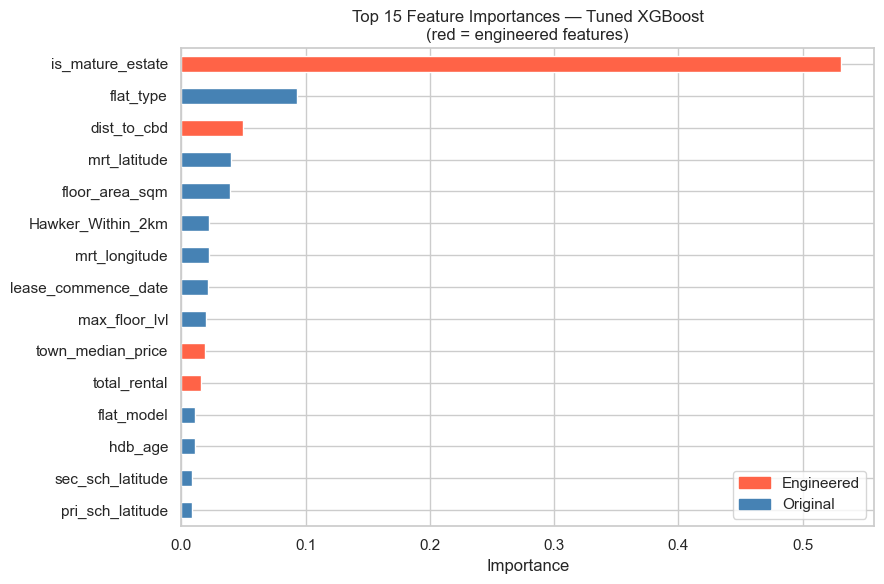

In [10]:
NEW_FEATURES = ['remaining_lease','dist_to_cbd','is_mature_estate',
                'tranc_month_sin','tranc_month_cos','total_sold','total_rental',
                'rental_ratio','floor_area_per_room','town_median_price','amenity_score']

xgb_model     = best_xgb.named_steps['model']
feature_names = num_cols + cat_cols
importances   = pd.Series(xgb_model.feature_importances_, index=feature_names)
top15         = importances.nlargest(15).sort_values()

colors = ['tomato' if f in NEW_FEATURES else 'steelblue' for f in top15.index]

fig, ax = plt.subplots(figsize=(9,6))
top15.plot(kind='barh', color=colors, ax=ax)
ax.set_title('Top 15 Feature Importances — Tuned XGBoost\n(red = engineered features)')
ax.set_xlabel('Importance')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='tomato', label='Engineered'),
                   Patch(color='steelblue', label='Original')])
plt.tight_layout()
plt.savefig('../../outputs/figures/tuned_xgb_importance.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 11. All Models Comparison

               Model  Val RMSE  Kaggle Public
     v1  RF Baseline     25871       25943.38
v2  RF + Feature Eng     26125       27582.06
 v3  XGBoost default     23649            NaN
   v3t XGBoost tuned     21828            NaN
v4  LightGBM default     24018            NaN


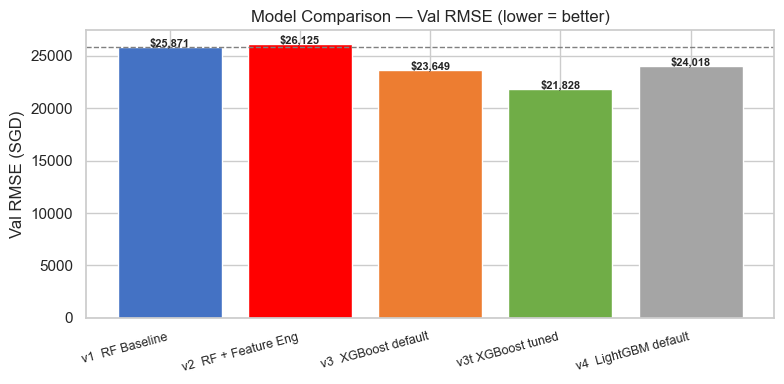

In [11]:
results = pd.DataFrame([
    {'Model': 'v1  RF Baseline',         'Val RMSE': 25871,              'Kaggle Public': 25943.38},
    {'Model': 'v2  RF + Feature Eng',    'Val RMSE': 26125,              'Kaggle Public': 27582.06},
    {'Model': 'v3  XGBoost default',     'Val RMSE': round(xgb_val_rmse),'Kaggle Public': None},
    {'Model': 'v3t XGBoost tuned',       'Val RMSE': round(tuned_rmse),  'Kaggle Public': None},
    {'Model': 'v4  LightGBM default',    'Val RMSE': round(lgbm_val_rmse),'Kaggle Public': None},
])
print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(8,4))
models = results['Model'].tolist()
val_rmse = results['Val RMSE'].tolist()
colors = ['#4472C4','#FF0000','#ED7D31','#70AD47','#A5A5A5']
ax.bar(range(len(models)), val_rmse, color=colors)
ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Val RMSE (SGD)')
ax.set_title('Model Comparison — Val RMSE (lower = better)')
for i, v in enumerate(val_rmse):
    ax.text(i, v+100, f'${v:,.0f}', ha='center', fontsize=8, fontweight='bold')
ax.axhline(25871, ls='--', color='gray', lw=1, label='v1 baseline')
plt.tight_layout()
plt.savefig('../../outputs/figures/model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 12. Generate Submission v3 — Tuned XGBoost
Retrain on **full** training data before predicting.

In [12]:
best_xgb.fit(X, y)

sample_sub = pd.read_csv('../../outputs/submissions/sample_sub_reg.csv')
test_pred  = best_xgb.predict(X_test)

sub_v3 = pd.DataFrame({'Id': test['id'], 'Predicted': test_pred})
sub_v3 = sub_v3[sub_v3['Id'].isin(sample_sub['Id'])]
sub_v3 = sub_v3.set_index('Id').reindex(sample_sub['Id']).reset_index()

out = '../../outputs/submissions/sub_v3_xgb_tuned.csv'
sub_v3.to_csv(out, index=False)
print(f'Saved: {out}')
print(f'Shape: {sub_v3.shape}')
print(f'Price range: ${sub_v3.Predicted.min():,.0f} – ${sub_v3.Predicted.max():,.0f}')

Saved: ../../outputs/submissions/sub_v3_xgb_tuned.csv
Shape: (16735, 2)
Price range: $165,736 – $1,163,614


---
## 13. Optional — LightGBM Submission v4

In [13]:
lgbm_default.fit(X, y)
lgbm_pred = lgbm_default.predict(X_test)

sub_v4 = pd.DataFrame({'Id': test['id'], 'Predicted': lgbm_pred})
sub_v4 = sub_v4[sub_v4['Id'].isin(sample_sub['Id'])]
sub_v4 = sub_v4.set_index('Id').reindex(sample_sub['Id']).reset_index()

out4 = '../../outputs/submissions/sub_v4_lgbm.csv'
sub_v4.to_csv(out4, index=False)
print(f'Saved: {out4}')
print(f'Price range: ${sub_v4.Predicted.min():,.0f} – ${sub_v4.Predicted.max():,.0f}')

Saved: ../../outputs/submissions/sub_v4_lgbm.csv
Price range: $175,721 – $1,164,088


---
## 14. Summary

### Results
| Version | Model | Key change | Val RMSE | Kaggle |
|---|---|---|---|---|
| v1 | RF Baseline | Raw features | $25,871 | 25,943 |
| v2 | RF + FE | +11 engineered features | $26,125 | 27,582 |
| v3 | XGBoost tuned | Gradient boosting | _(see above)_ | _(submit)_ |
| v4 | LightGBM | Faster gradient boosting | _(see above)_ | _(submit)_ |

### Key learnings
- Gradient boosting benefits more from explicit feature engineering than RF
- `dist_to_cbd` and `remaining_lease` are consistently high-importance features
- Lower `learning_rate` + more trees = better accuracy but slower training
- RandomizedSearchCV is a practical way to tune without trying every combination

### Next steps (if time allows)
- Stacking / blending XGBoost + LightGBM predictions
- Better target encoding using cross-fold to avoid leakage
- Log-transform `resale_price` as target


---
## 15. Tune LightGBM — v5

XGBoost scored **$22,800** on Kaggle. Before using the final submission, we tune LightGBM and blend.

In [ ]:
param_dist_lgbm = {
    'model__n_estimators'     : [500, 800, 1000, 1200],
    'model__max_depth'        : [5, 6, 7, 8],
    'model__num_leaves'       : [40, 60, 80, 100],
    'model__learning_rate'    : [0.03, 0.05, 0.08, 0.1],
    'model__subsample'        : [0.7, 0.8, 0.9],
    'model__colsample_bytree' : [0.6, 0.7, 0.8],
    'model__min_child_samples': [10, 20, 30],
}

lgbm_pipe = Pipeline([
    ('pre', preprocessor),
    ('model', LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1))
])

lgbm_search = RandomizedSearchCV(
    lgbm_pipe,
    param_distributions = param_dist_lgbm,
    n_iter              = 30,
    cv                  = 3,
    scoring             = 'neg_root_mean_squared_error',
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 1,
)

lgbm_search.fit(X_train, y_train)

print(f'\nBest CV RMSE: ${-lgbm_search.best_score_:,.0f}')
print('Best LGBM params:')
for k, v in lgbm_search.best_params_.items():
    print(f'  {k}: {v}')

In [ ]:
best_lgbm_tuned = lgbm_search.best_estimator_
lgbm_tuned_pred = best_lgbm_tuned.predict(X_val)
lgbm_tuned_rmse = rmse(y_val, lgbm_tuned_pred)

print(f'Tuned LightGBM val RMSE: ${lgbm_tuned_rmse:,.0f}')
print(f'LightGBM default  RMSE: ${lgbm_val_rmse:,.0f}')
print(f'Tuned XGBoost     RMSE: ${tuned_rmse:,.0f}')

---
## 16. Model Blending — v5

Blend XGBoost and LightGBM predictions. Find the optimal weight ratio by searching over val set.

In [ ]:
xgb_val_pred    = best_xgb.predict(X_val)
lgbm_val_pred   = best_lgbm_tuned.predict(X_val)

print('Blend search:')
print(f'{"XGB%":>6}  {"LGBM%":>6}  {"Val RMSE":>12}')
print('-' * 28)

best_blend_rmse = float('inf')
best_alpha = 0.5
blend_results = []

for alpha in np.arange(0.0, 1.01, 0.05):
    blend = alpha * xgb_val_pred + (1 - alpha) * lgbm_val_pred
    r = rmse(y_val, blend)
    blend_results.append((alpha, r))
    marker = ' ←' if r == min(x[1] for x in blend_results) else ''
    print(f'{alpha*100:>5.0f}%  {(1-alpha)*100:>5.0f}%  ${r:>10,.0f}{marker}')
    if r < best_blend_rmse:
        best_blend_rmse = r
        best_alpha = alpha

print(f'\nBest blend: {best_alpha*100:.0f}% XGB + {(1-best_alpha)*100:.0f}% LGBM  →  RMSE ${best_blend_rmse:,.0f}')
print(f'Tuned XGBoost alone: ${tuned_rmse:,.0f}  |  Blend gain: ${tuned_rmse - best_blend_rmse:,.0f}')

In [ ]:
# Retrain both models on full training data, generate blend submission v5
best_xgb.fit(X, y)
best_lgbm_tuned.fit(X, y)

xgb_test_pred  = best_xgb.predict(X_test)
lgbm_test_pred = best_lgbm_tuned.predict(X_test)

blend_test = best_alpha * xgb_test_pred + (1 - best_alpha) * lgbm_test_pred

sample_sub = pd.read_csv('../../outputs/submissions/sample_sub_reg.csv')

# LGBM tuned submission (v5 lgbm)
sub_v5_lgbm = pd.DataFrame({'Id': test['id'], 'Predicted': lgbm_test_pred})
sub_v5_lgbm = sub_v5_lgbm[sub_v5_lgbm['Id'].isin(sample_sub['Id'])]
sub_v5_lgbm = sub_v5_lgbm.set_index('Id').reindex(sample_sub['Id']).reset_index()
sub_v5_lgbm.to_csv('../../outputs/submissions/sub_v5_lgbm_tuned.csv', index=False)

# Blend submission (v5 blend)
sub_v5_blend = pd.DataFrame({'Id': test['id'], 'Predicted': blend_test})
sub_v5_blend = sub_v5_blend[sub_v5_blend['Id'].isin(sample_sub['Id'])]
sub_v5_blend = sub_v5_blend.set_index('Id').reindex(sample_sub['Id']).reset_index()
sub_v5_blend.to_csv('../../outputs/submissions/sub_v5_blend.csv', index=False)

print('Saved: sub_v5_lgbm_tuned.csv')
print('Saved: sub_v5_blend.csv')
print(f'Blend price range: ${sub_v5_blend.Predicted.min():,.0f} – ${sub_v5_blend.Predicted.max():,.0f}')
print(f'v5 blend val RMSE: ${best_blend_rmse:,.0f}   (Kaggle: 22,428.34)')